In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#reading train data
train = pd.read_csv('train.csv', encoding="cp1252")
print(train.shape)
train.sample(5)

(27481, 10)


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
18635,8982cde761,I saw the show listing and saw it was on a We...,I saw the show listing and saw it was on a Wed...,neutral,night,70-100,Madagascar,27691018,581795.0,48
23321,1d94a35f7e,_KittyKat That`s very nice of him.,That`s very nice of him.,positive,night,70-100,Namibia,2540905,823000.0,3
15339,daa58bb5d7,heyy its ur bday?!!happy birthday!,!happy,positive,morning,46-60,Mauritania,4649658,1030700.0,5
24414,adb113b997,Hello there! Thankyou. I always seem to make ...,Thankyou.,positive,morning,0-20,Micronesia,115023,700.0,164
13045,478a86ef47,I want my real keys back,I want my real keys back,neutral,noon,21-30,Japan,126476461,364555.0,347


In [3]:
#reading test data
import pandas as pd
test = pd.read_csv('test.csv', encoding='latin-1')
print(test.shape)
test.head()

(4815, 9)


,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [4]:
# data description for numerical vlaues
train.describe()

,Population -2020,Land Area (Km²),Density (P/Km²)
count,2.748100e+04,2.748100e+04,27481.000000
mean,4.018497e+07,6.621730e+05,357.686583
std,1.504946e+08,1.807425e+06,2013.750702
min,8.010000e+02,0.000000e+00,2.000000
25%,1.968001e+06,2.281000e+04,35.000000
50%,8.655535e+06,1.118900e+05,89.000000
75%,2.843594e+07,5.279700e+05,214.000000
max,1.439324e+09,1.637687e+07,26337.000000


In [5]:
train.describe(include = ['string'])

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country
count,27481,27480,27480,27481,27481,27481,27481
unique,27481,27480,22430,3,3,6,195
top,cb774db0d1,"I`d have responded, if I were going",good,neutral,morning,0-20,Afghanistan
freq,1,1,199,11118,9161,4581,149


In [6]:
# data info
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            27481 non-null  str    
 1   text              27480 non-null  str    
 2   selected_text     27480 non-null  str    
 3   sentiment         27481 non-null  str    
 4   Time of Tweet     27481 non-null  str    
 5   Age of User       27481 non-null  str    
 6   Country           27481 non-null  str    
 7   Population -2020  27481 non-null  int64  
 8   Land Area (Km²)   27481 non-null  float64
 9   Density (P/Km²)   27481 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 2.1 MB


  NO null Values

# EDA

In [7]:
train.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [8]:
#checking null values
train.isnull().sum()

textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

In [9]:
#exlcuding null values
train = train[~train.text.isnull()]

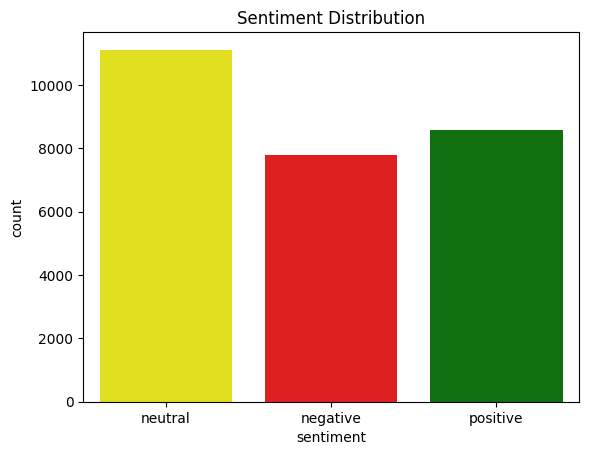

In [10]:
#sentiment values count
sns.countplot(data=train, x='sentiment', hue='sentiment', palette={'negative': 'red', 'positive': 'green','neutral':'yellow'}),
plt.title("Sentiment Distribution");

No Class Imabalance

In [11]:
#average age according to type of sentiment
train['Age of User'].unique()

<StringArray>
['0-20', '21-30', '31-45', '46-60', '60-70', '70-100']
Length: 6, dtype: str

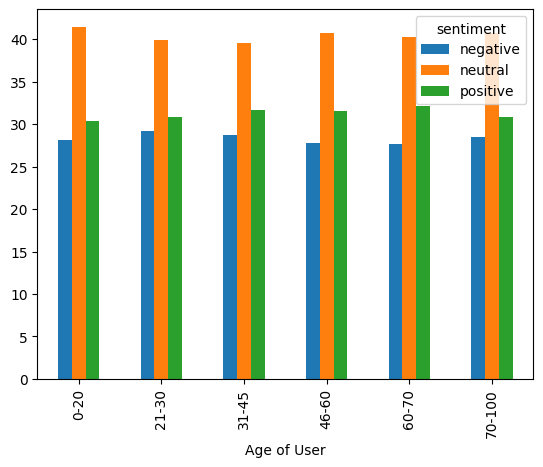

In [12]:
# average sentiment by age
((train.groupby(['Age of User','sentiment'])['sentiment'].value_counts())/train.groupby(['Age of User'])['Age of User'].value_counts() * 100).unstack().plot(kind = 'bar', stacked  = False);